In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("Tools loaded successfully!")

Tools loaded successfully!


In [2]:
df = pd.read_csv("kenya_education_data.csv")
df.head()

,County,Region,Primary_Enrollment_Rate,Secondary_Enrollment_Rate,Dropout_Rate_Primary,Dropout_Rate_Secondary,Pupil_Teacher_Ratio_Primary,Pupil_Teacher_Ratio_Secondary,Literacy_Rate,Schools_Count
0,Nairobi,Nairobi,94.2,72.1,5.8,18.3,42,31,87.3,1247
1,Mombasa,Coast,88.6,61.4,11.4,24.7,48,38,79.2,423
2,Kisumu,Nyanza,86.3,58.2,13.7,27.4,51,41,76.8,612
3,Nakuru,Rift Valley,89.1,63.7,10.9,22.6,46,35,80.4,891
4,Eldoret (Uasin Gishu),Rift Valley,87.4,60.9,12.6,24.1,49,39,78.6,543


In [3]:
df.shape

(48, 10)

In [4]:
df.describe()

,Primary_Enrollment_Rate,Secondary_Enrollment_Rate,Dropout_Rate_Primary,Dropout_Rate_Secondary,Pupil_Teacher_Ratio_Primary,Pupil_Teacher_Ratio_Secondary,Literacy_Rate,Schools_Count
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,80.341667,51.993750,19.658333,33.610417,56.979167,46.541667,69.750000,399.083333
std,9.557949,11.103812,9.557949,10.338880,9.075310,8.795449,11.146338,228.103171
min,54.700000,24.900000,5.800000,17.600000,42.000000,31.000000,40.100000,98.000000
25%,76.025000,45.400000,13.775000,27.250000,51.000000,41.000000,64.475000,234.000000
50%,83.500000,54.450000,16.500000,30.750000,55.000000,45.000000,72.900000,334.000000
75%,86.225000,58.475000,23.975000,39.025000,63.250000,52.250000,76.500000,494.750000
max,94.200000,72.100000,45.300000,59.800000,79.000000,67.000000,87.300000,1247.000000


In [5]:
worst_dropout = df[['County', 'Dropout_Rate_Primary', 'Dropout_Rate_Secondary']].sort_values('Dropout_Rate_Primary', ascending=False).head(10)
print("Top 10 Counties with Highest Primary Dropout Rates:")
print(worst_dropout)

Top 10 Counties with Highest Primary Dropout Rates:
        County  Dropout_Rate_Primary  Dropout_Rate_Secondary
14     Mandera                  45.3                    59.8
13       Wajir                  41.8                    56.1
15     Turkana                  40.2                    54.7
12     Garissa                  38.6                    52.4
16    Marsabit                  36.8                    51.3
17     Samburu                  34.6                    49.8
18  Tana River                  32.2                    47.6
19      Isiolo                  30.7                    46.1
46        Lamu                  28.4                    43.8
36  West Pokot                  27.7                    42.6


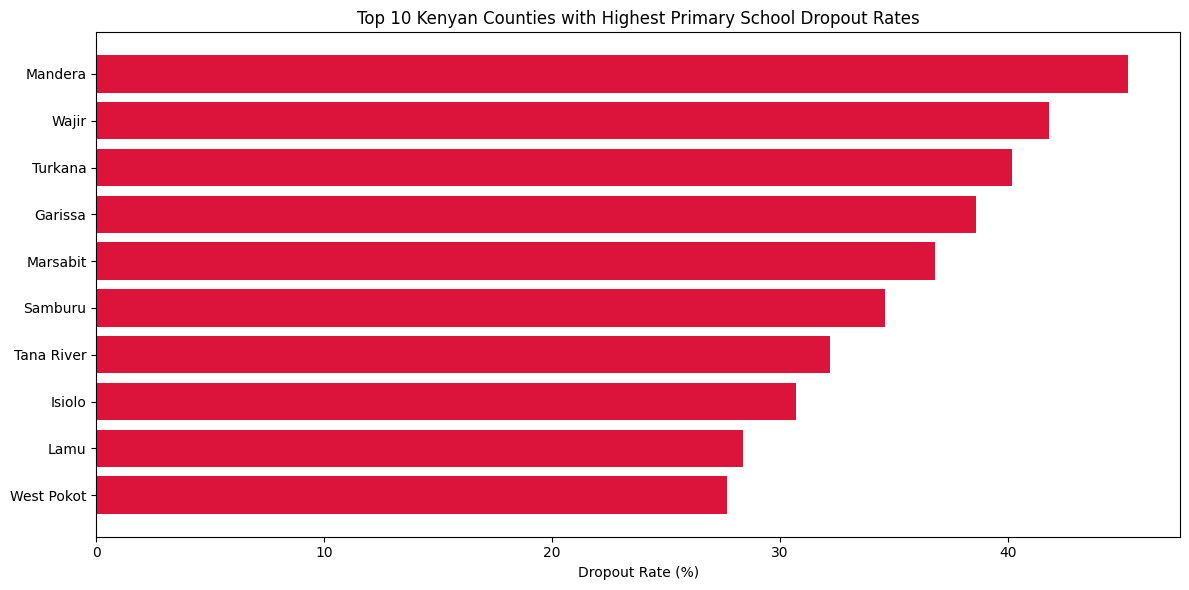

In [6]:
plt.figure(figsize=(12, 6))
plt.barh(worst_dropout['County'], worst_dropout['Dropout_Rate_Primary'], color='crimson')
plt.xlabel('Dropout Rate (%)')
plt.title('Top 10 Kenyan Counties with Highest Primary School Dropout Rates')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
region_stats = df.groupby('Region')[['Primary_Enrollment_Rate', 'Dropout_Rate_Primary']].mean().round(2)
print(region_stats)

               Primary_Enrollment_Rate  Dropout_Rate_Primary
Region                                                      
Central                          90.64                  9.36
Coast                            76.43                 23.57
Eastern                          80.47                 19.53
Nairobi                          94.20                  5.80
North Eastern                    58.10                 41.90
Nyanza                           84.37                 15.63
Rift Valley                      79.59                 20.41
Western                          82.88                 17.12


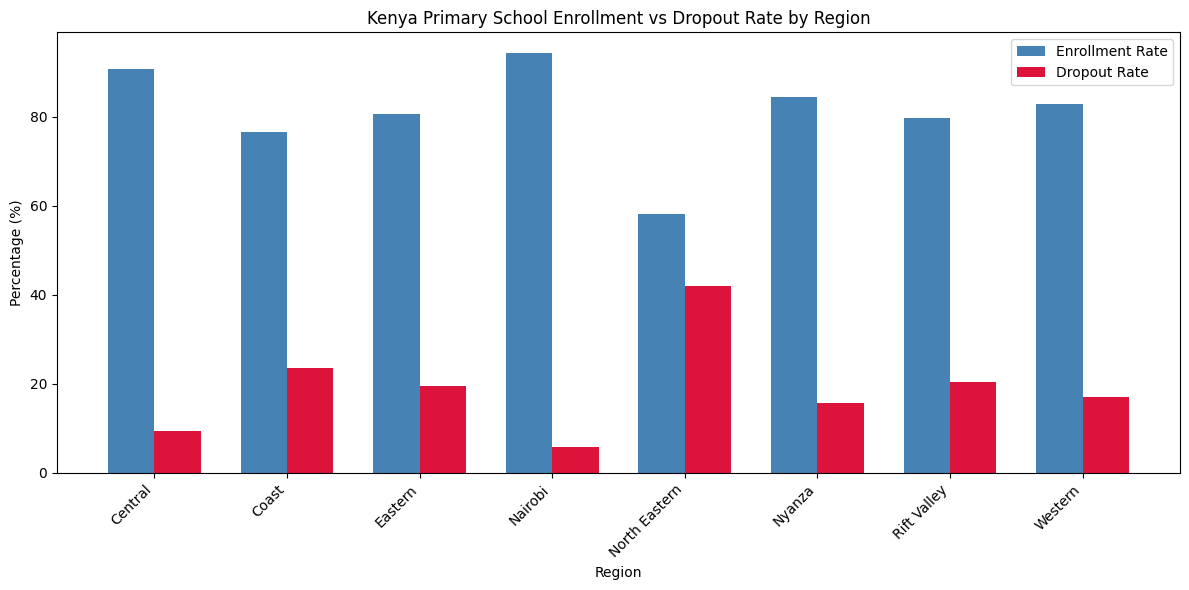

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(region_stats.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], region_stats['Primary_Enrollment_Rate'], width, label='Enrollment Rate', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], region_stats['Dropout_Rate_Primary'], width, label='Dropout Rate', color='crimson')

ax.set_xlabel('Region')
ax.set_ylabel('Percentage (%)')
ax.set_title('Kenya Primary School Enrollment vs Dropout Rate by Region')
ax.set_xticks(x)
ax.set_xticklabels(region_stats.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

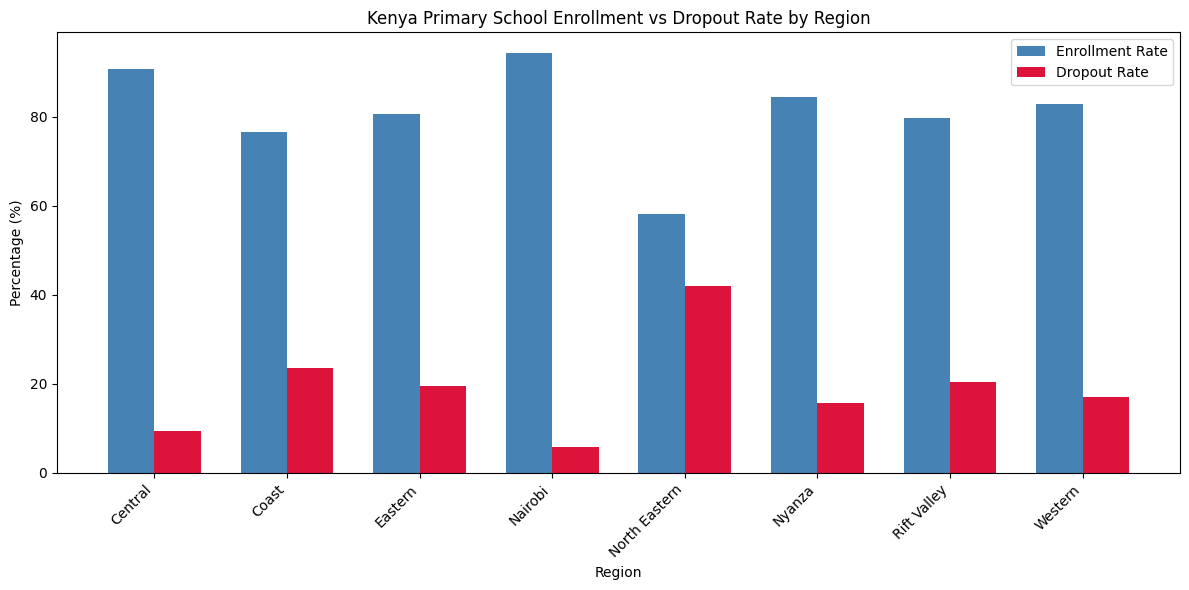

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(region_stats.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], region_stats['Primary_Enrollment_Rate'], width, label='Enrollment Rate', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], region_stats['Dropout_Rate_Primary'], width, label='Dropout Rate', color='crimson')

ax.set_xlabel('Region')
ax.set_ylabel('Percentage (%)')
ax.set_title('Kenya Primary School Enrollment vs Dropout Rate by Region')
ax.set_xticks(x)
ax.set_xticklabels(region_stats.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
print("=" * 60)
print("KENYA EDUCATION DATA ANALYSIS — SAINT SYSTEMS")
print("=" * 60)
print()
print(f"Total counties analysed: {len(df)}")
print()
print(f"ENROLLMENT:")
print(f"  Average primary enrollment rate:     {df['Primary_Enrollment_Rate'].mean():.1f}%")
print(f"  Average secondary enrollment rate:   {df['Secondary_Enrollment_Rate'].mean():.1f}%")
print(f"  Best performing county:              {df.loc[df['Primary_Enrollment_Rate'].idxmax(), 'County']} ({df['Primary_Enrollment_Rate'].max()}%)")
print(f"  Worst performing county:             {df.loc[df['Primary_Enrollment_Rate'].idxmin(), 'County']} ({df['Primary_Enrollment_Rate'].min()}%)")
print()
print(f"DROPOUT:")
print(f"  Average primary dropout rate:        {df['Dropout_Rate_Primary'].mean():.1f}%")
print(f"  Average secondary dropout rate:      {df['Dropout_Rate_Secondary'].mean():.1f}%")
print(f"  Highest dropout county:              {df.loc[df['Dropout_Rate_Primary'].idxmax(), 'County']} ({df['Dropout_Rate_Primary'].max()}%)")
print()
print(f"TEACHER SHORTAGE:")
print(f"  Average pupils per teacher (primary):{df['Pupil_Teacher_Ratio_Primary'].mean():.0f} students")
print(f"  Worst ratio in Kenya:                {df['Pupil_Teacher_Ratio_Primary'].max():.0f} students per teacher")
print()
print("CONCLUSION:")
print("  North Eastern Kenya shows the most critical education gaps.")
print("  Nearly 1 in 5 primary school children drops out nationally.")
print("  Teacher shortages are severe — up to 79 students per teacher.")
print("  These are the communities SAINT SYSTEMS is built to serve.")
print("=" * 60)

KENYA EDUCATION DATA ANALYSIS — SAINT SYSTEMS

Total counties analysed: 48

ENROLLMENT:
  Average primary enrollment rate:     80.3%
  Average secondary enrollment rate:   52.0%
  Best performing county:              Nairobi (94.2%)
  Worst performing county:             Mandera (54.7%)

DROPOUT:
  Average primary dropout rate:        19.7%
  Average secondary dropout rate:      33.6%
  Highest dropout county:              Mandera (45.3%)

TEACHER SHORTAGE:
  Average pupils per teacher (primary):57 students
  Worst ratio in Kenya:                79 students per teacher

CONCLUSION:
  North Eastern Kenya shows the most critical education gaps.
  Nearly 1 in 5 primary school children drops out nationally.
  Teacher shortages are severe — up to 79 students per teacher.
  These are the communities SAINT SYSTEMS is built to serve.
